## Numerical Analysis - Spring semester 2026
# Serie 04 - Sensitivity of linear systems

First, we will need to import some of the usual packages. You will have to run this cell every time you restart your notebook.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

<hr style="clear:both">

### An ill-conditioned linear system

We consider the Vandermonde matrix

$$
A = \begin{bmatrix}
  1 & t_1 & t_1^2 & \cdots & t_1^{n-1}\\
  1 & t_2 & t_2^2 & \cdots & t_2^{n-1} \\
  \vdots & \vdots & \vdots & \ddots  & \vdots \\
  1 & t_n & t_n^2 & \cdots & t_n^{n-1} 
\end{bmatrix} \in \mathbb{R}^{n\times n},
$$

where the points $t_1, \ldots, t_n$ are equispaced in the interval $[0, 1]$. For a set of points `t`, the Vandermonde matrix can be generated with `A = np.vander(t, increasing=True)`

We want to solve the linear system $A\mathbf{x}=\mathbf{b}$ for $\mathbf{x}$ where
$$
\mathbf{b} = \begin{bmatrix}
  1+t_1^2 \\
  1+t_2^2 \\
  \vdots \\
  1+t_n^2 
\end{bmatrix}  \in \mathbb{R}^{n}.
$$
Clearly, the exact solution is $\mathbf{x}=(1,0,1,0\ldots,0)^\top \in \mathbb{R}^{n}$.

<div class="alert alert-success">
    
**Exercise 1:** For $n=4$, solve the linear system numerically using the command `np.linalg.solve`. Let $\mathbf{x_c}$ be the obtained solution. Compute the relative error $\varepsilon=\|\mathbf{x_c}-\mathbf{x}\| / \|\mathbf{x}\|$, where $\|\cdot\|$ is the $2$-norm. 

*Hint:* The $2$-norm of a vector can be computed with the NumPy command `np.linalg.norm`.
</div>


In [2]:
### BEGIN SOLUTION
n = 4
t = np.linspace(0, 1, n)
A = np.vander(t, increasing=True)
b = 1 + t ** 2

x_c = np.linalg.solve(A, b)

x_ex = np.zeros(n)
x_ex[[0, 2]] = 1
err = np.linalg.norm(x_c - x_ex) / np.linalg.norm(x_ex)

print(r"relative error of obtained solution: ε = {:.4e}".format(err))
### END SOLUTION

relative error of obtained solution: ε = 1.0607e-15


<div class="alert alert-success">
    
**Exercise 2:** For the same linear system but for matrix sizes $n=4, 6, 8, \ldots, 20$, visualize the relative error $\varepsilon$ and the condition number in the $2$-norm as functions of $n$, in two graphs, one in logarithmic scale (`plt.loglog`) and one in semi-logarithmic scale (`plt.semilogy`). What type of growth do we see for the  error $\varepsilon$?
</div>

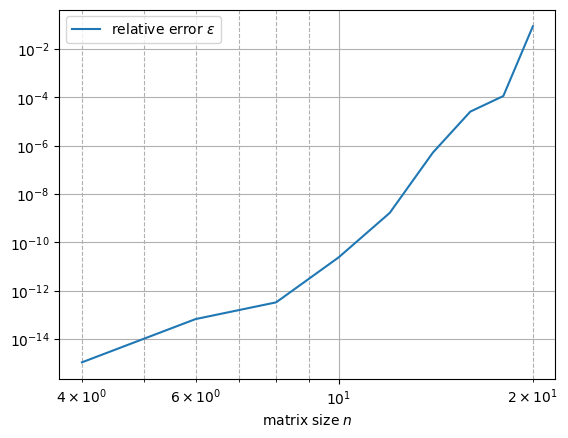

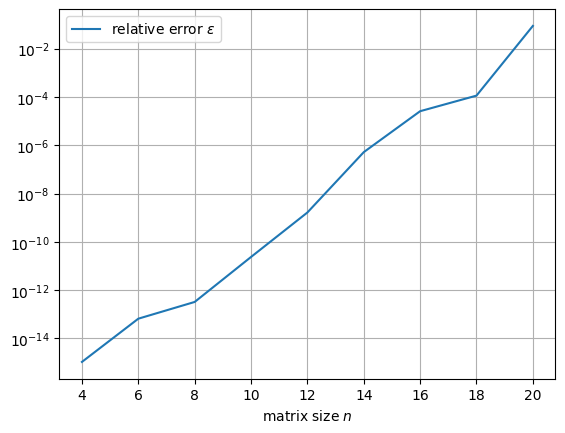

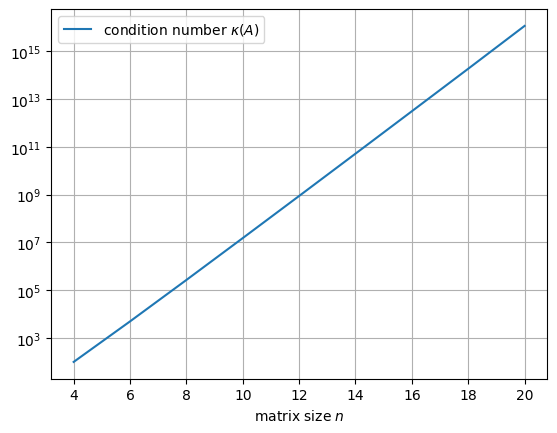

In [8]:
### BEGIN SOLUTION
n_list = 2 * np.arange(2, 11)

err_list = []
cond_list = []

for n in n_list:

    x = np.linspace(0, 1, n)
    A = np.vander(x, increasing=True)   
    b = 1 + x ** 2
    x_ex = np.zeros(n)
    x_ex[[0, 2]] = 1
    
    cond_A = np.linalg.cond(A) 
    x_c = np.linalg.solve(A, b)
    
    err_list.append(np.linalg.norm(x_c - x_ex) / np.linalg.norm(x_ex))
    cond_list.append(cond_A)

plt.loglog(n_list, err_list, label=r"relative error $\varepsilon$")
plt.legend()
plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="--")
plt.xlabel(r"matrix size $n$")
plt.show()

plt.semilogy(n_list, err_list, label=r"relative error $\varepsilon$")
plt.legend()
plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="--")
plt.xlabel(r"matrix size $n$")
plt.show()

plt.semilogy(n_list, cond_list, label=r"condition number $\kappa(A)$")
plt.legend()
plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="--")
plt.xlabel(r"matrix size $n$")
plt.show()

# We notice that the relative error as well as the condition number grow linearly in
# the graph in semi-logarithmic scale, which shows that the growth of the relative error
# is exponential: ε ≈ exp(αn) for some α > 0.

### END SOLUTION

<hr style="clear:both">

## The end

Congratulations! You have made it to the end of the fourth exercise notebook. 